<a href="https://colab.research.google.com/github/Siva-p-11/ML-assiments/blob/main/experiment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Output()


Bayesian Logistic Regression Summary:
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha   -0.526  0.089  -0.682   -0.355      0.002    0.002    2366.0   
beta[0] -0.778  0.116  -0.987   -0.552      0.003    0.002    1568.0   
beta[1] -0.509  0.099  -0.692   -0.322      0.002    0.002    1779.0   
beta[2] -0.235  0.108  -0.445   -0.043      0.002    0.002    2379.0   
beta[3]  0.184  0.092   0.015    0.362      0.002    0.002    2155.0   
beta[4]  0.305  0.142   0.053    0.584      0.003    0.003    1826.0   

         ess_tail  r_hat  
alpha      1315.0    1.0  
beta[0]    1506.0    1.0  
beta[1]    1338.0    1.0  
beta[2]    1349.0    1.0  
beta[3]    1578.0    1.0  
beta[4]    1529.0    1.0  

Bayesian Logistic Regression Accuracy: 0.6759776536312849

Bayesian Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       110
           1       0.62      0.41      0.49   

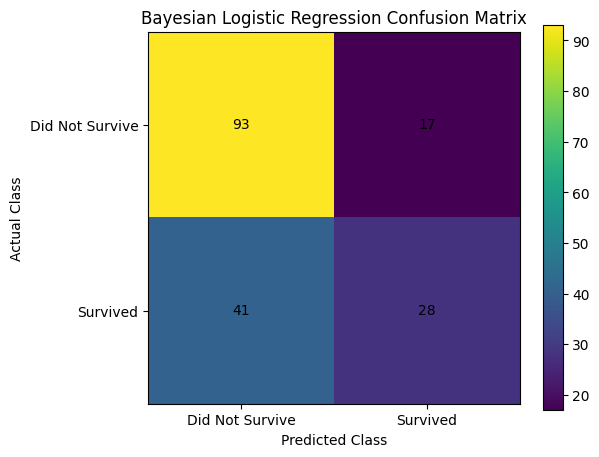

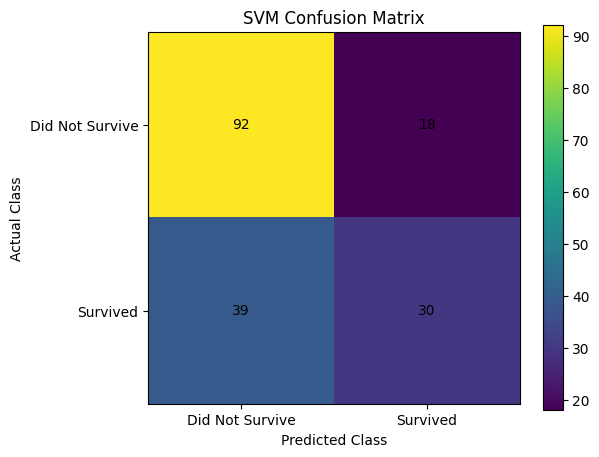


Insights:
1. Bayesian Logistic Regression is used for binary classification.
2. Bayesian Logistic Regression uses prior and posterior distributions.
3. SVM finds an optimal decision boundary between different classes.
4. Feature scaling improves SVM performance.
5. The target variable is Survived, where 0 means did not survive and 1 means survived.
6. Accuracy is used to evaluate the classification models.
7. Confusion matrices show correct and incorrect predictions.
8. Bayesian Logistic Regression and SVM are compared using their accuracy.


In [1]:
# Name         : Siva P
# Reg No       : RA2411026010775
# Subject      : Machine Learning
# Subject Code : 21CSC305P
# Section      : AN1
#
# Practice 4:
# Implement Bayesian Logistic Regression and SVM for classification.

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pymc as pm
import arviz as az

# Load the Titanic dataset

df = pd.read_csv("train.csv")

# Select required columns

df = df[
    ["Pclass", "Age", "SibSp", "Parch", "Fare", "Survived"]
]

# Handle missing values in Age

df["Age"] = df["Age"].fillna(df["Age"].mean())

# Define independent (X) and dependent (y) variables

X = df[
    ["Pclass", "Age", "SibSp", "Parch", "Fare"]
]

y = df["Survived"]

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# BAYESIAN LOGISTIC REGRESSION
# =========================================================

# Create Bayesian Logistic Regression model

with pm.Model() as bayesian_model:

    # Prior for intercept

    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=5
    )

    # Prior for coefficients

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=2,
        shape=X_train_scaled.shape[1]
    )

    # Logistic regression equation

    logit_p = alpha + pm.math.dot(
        X_train_scaled,
        beta
    )

    # Bernoulli likelihood

    y_obs = pm.Bernoulli(
        "y_obs",
        logit_p=logit_p,
        observed=y_train.values
    )

    # Perform Bayesian inference

    trace = pm.sample(
        1000,
        tune=1000,
        random_seed=42,
        target_accept=0.9,
        progressbar=True
    )

# Display Bayesian model summary

print("\nBayesian Logistic Regression Summary:")

print(
    az.summary(
        trace,
        var_names=["alpha", "beta"]
    )
)

# Get posterior mean values

alpha_mean = trace.posterior["alpha"].mean().item()

beta_mean = (
    trace.posterior["beta"]
    .mean(dim=("chain", "draw"))
    .values
)

# Calculate prediction probabilities

logit_test = (
    alpha_mean +
    np.dot(X_test_scaled, beta_mean)
)

probabilities = 1 / (1 + np.exp(-logit_test))

# Convert probabilities into classes

y_pred_bayes = (
    probabilities >= 0.5
).astype(int)

# Calculate accuracy

bayes_accuracy = accuracy_score(
    y_test,
    y_pred_bayes
)

print(
    "\nBayesian Logistic Regression Accuracy:",
    bayes_accuracy
)

# Classification report

print("\nBayesian Logistic Regression Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_bayes
    )
)

# =========================================================
# SUPPORT VECTOR MACHINE
# =========================================================

# Create SVM model

svm_model = SVC(
    kernel="linear",
    random_state=42
)

# Train the SVM model

svm_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions

y_pred_svm = svm_model.predict(
    X_test_scaled
)

# Calculate SVM accuracy

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("\nSVM Accuracy:", svm_accuracy)

# Classification report

print("\nSVM Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

# =========================================================
# CONFUSION MATRICES
# =========================================================

# Bayesian Logistic Regression confusion matrix

bayes_cm = confusion_matrix(
    y_test,
    y_pred_bayes
)

print(
    "\nBayesian Logistic Regression Confusion Matrix:"
)

print(bayes_cm)

# SVM confusion matrix

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("\nSVM Confusion Matrix:")

print(svm_cm)

# =========================================================
# MODEL COMPARISON
# =========================================================

print("\nModel Comparison")
print("------------------------------")

print(
    "Bayesian Logistic Regression Accuracy:",
    bayes_accuracy
)

print(
    "SVM Accuracy:",
    svm_accuracy
)

# =========================================================
# VISUALIZATION
# =========================================================

# Plot Bayesian Logistic Regression confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(
    bayes_cm,
    interpolation="nearest"
)

plt.title(
    "Bayesian Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            bayes_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

# Plot SVM confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(
    svm_cm,
    interpolation="nearest"
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            svm_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

# =========================================================
# INSIGHTS
# =========================================================

print("\nInsights:")

print(
    "1. Bayesian Logistic Regression is used for binary classification."
)

print(
    "2. Bayesian Logistic Regression uses prior and posterior distributions."
)

print(
    "3. SVM finds an optimal decision boundary between different classes."
)

print(
    "4. Feature scaling improves SVM performance."
)

print(
    "5. The target variable is Survived, where 0 means did not survive and 1 means survived."
)

print(
    "6. Accuracy is used to evaluate the classification models."
)

print(
    "7. Confusion matrices show correct and incorrect predictions."
)

print(
    "8. Bayesian Logistic Regression and SVM are compared using their accuracy."
)